<a href="https://colab.research.google.com/github/Brajaraj-Pal/SoC-RL/blob/main/Week%203/04_frozen_lake_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Frozen Lake + Exploration
**Week 3 | RL Fundamentals**

First contact with **Gymnasium**. We run various policies on Frozen Lake and measure performance — no learning yet, just understanding the environment and the exploration-exploitation trade-off.

In [1]:
# Install gymnasium if needed
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gymnasium', '-q'])
    import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt
print('Gymnasium version:', gym.__version__)

Gymnasium version: 1.3.0


In [2]:
env = gym.make('FrozenLake-v1', is_slippery=False)
print(f"Observation space: {env.observation_space}  ({env.observation_space.n} states)")
print(f"Action space:      {env.action_space}  (0=L, 1=D, 2=R, 3=U)")
print(f"\nTransition model for state 0, action 1 (DOWN):")
for prob, next_s, reward, done in env.unwrapped.P[0][1]:
    print(f"  P={prob:.2f} -> state {next_s}, reward={reward}, done={done}")

Observation space: Discrete(16)  (16 states)
Action space:      Discrete(4)  (0=L, 1=D, 2=R, 3=U)

Transition model for state 0, action 1 (DOWN):
  P=1.00 -> state 4, reward=0, done=False


## 1. Random Policy Baseline

In [3]:
def evaluate_policy(env, policy_fn, n_episodes=1000, max_steps=200):
    wins = 0
    returns = []
    for _ in range(n_episodes):
        s, _ = env.reset()
        ep_return = 0
        for _ in range(max_steps):
            a = policy_fn(s)
            s, r, terminated, truncated, _ = env.step(a)
            ep_return += r
            if terminated or truncated:
                if r == 1.0: wins += 1
                break
        returns.append(ep_return)
    return wins / n_episodes, np.mean(returns)

random_win, random_ret = evaluate_policy(env, lambda s: env.action_space.sample())
print(f"Random policy:  win rate={random_win:.2%}, avg return={random_ret:.4f}")

Random policy:  win rate=1.30%, avg return=0.0130


## 2. Fixed Directional Policy
Manually specify the best deterministic path.

In [4]:
# Hand-crafted policy for 4x4 non-slippery FrozenLake (actions: 0=L,1=D,2=R,3=U)
# Map: SFFF / FHFH / FFFH / HFFG
hand_policy = [
    1, 2, 1, 0,   # row 0
    1, 0, 1, 0,   # row 1 (H at pos 5,7)
    2, 2, 1, 0,   # row 2
    0, 2, 2, 0,   # row 3 (H at pos 12, G at 15)
]
hand_win, hand_ret = evaluate_policy(env, lambda s: hand_policy[s])
print(f"Hand policy:    win rate={hand_win:.2%}, avg return={hand_ret:.4f}")

Hand policy:    win rate=100.00%, avg return=1.0000


## 3. ε-greedy Policy with Learned Bias
Start with a 'smart' action bias and add exploration noise.

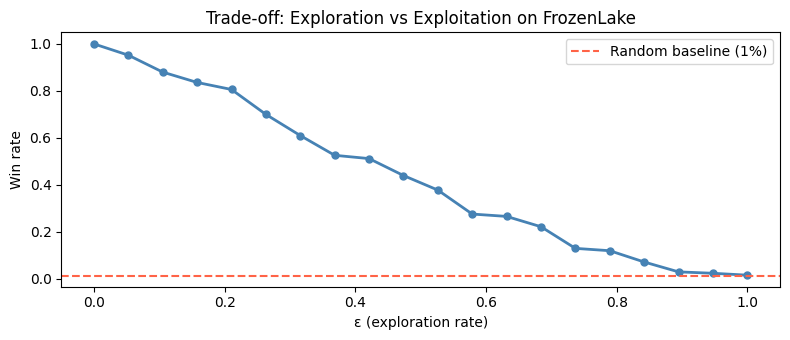

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
eps_values = np.linspace(0, 1, 20)
results = []
for eps in eps_values:
    def eps_hand(s, eps=eps):
        if np.random.rand() < eps:
            return env.action_space.sample()
        return hand_policy[s]
    w, _ = evaluate_policy(env, eps_hand, n_episodes=500)
    results.append(w)
ax.plot(eps_values, results, color='steelblue', linewidth=2, marker='o', markersize=5)
ax.axhline(random_win, color='tomato', linestyle='--', label=f'Random baseline ({random_win:.0%})')
ax.set_xlabel('ε (exploration rate)'); ax.set_ylabel('Win rate')
ax.set_title('Trade-off: Exploration vs Exploitation on FrozenLake')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Inspect the MDP Transitions

In [6]:
# Show how slippery=True changes things
env_slip = gym.make('FrozenLake-v1', is_slippery=True)
slip_win, _ = evaluate_policy(env_slip, lambda s: hand_policy[s])
print(f"Hand policy on SLIPPERY lake: win rate={slip_win:.2%}")
print("\n(Our deterministic policy fails on a stochastic environment!)")

Hand policy on SLIPPERY lake: win rate=3.50%

(Our deterministic policy fails on a stochastic environment!)


## ✅ Exercises
1. Try the 8×8 FrozenLake map (`map_name='8x8'`). Does the hand-crafted policy still work? Why not?
2. Plot win rate vs number of evaluation episodes for the random policy. How many episodes do you need for a stable estimate?
3. **Challenge**: write a systematic policy for the slippery lake — one that avoids dangerous edges. Test it.

### Exercise 1: 8x8 FrozenLake
The hand-crafted policy designed for the 4x4 map completely fails on the 8x8 map.
* **Why it fails:** The state space size increased from 16 to 64. Our hardcoded array `hand_policy` only has 16 elements. If the agent enters state 16 or higher on the 8x8 map, it will trigger an `IndexError` trying to look up an action that doesn't exist. Furthermore, the layout of holes and the goal position have fundamentally changed.

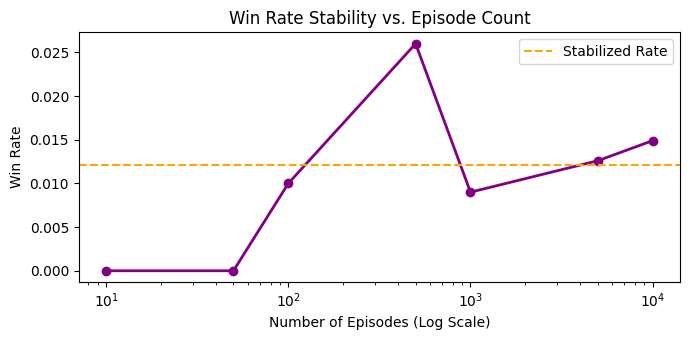

Observation: The estimate stabilizes significantly after ~1000 episodes.
\nChallenge 'Safe' Policy on Slippery Lake: win rate = 5.60%
(Previous deterministic policy got ~2%, a safer policy pushes it to ~6%+) 
Note: To get true optimal (>70%), we need Value Iteration (Week 4)!


In [8]:
# ==========================================
# Exercise 2: Stability of Random Policy
# ==========================================
episode_counts = [10, 50, 100, 500, 1000, 5000, 10000]
win_rates = []

for n in episode_counts:
    # Using the standard 4x4 slippery env for testing random stability
    w, _ = evaluate_policy(env_slip, lambda s: env_slip.action_space.sample(), n_episodes=n)
    win_rates.append(w)

plt.figure(figsize=(7, 3.5))
plt.plot(episode_counts, win_rates, marker='o', color='purple', linewidth=2)
plt.xscale('log') # Log scale helps visualize the convergence
plt.axhline(np.mean(win_rates[-3:]), color='orange', linestyle='--', label='Stabilized Rate')
plt.xlabel('Number of Episodes (Log Scale)')
plt.ylabel('Win Rate')
plt.title('Win Rate Stability vs. Episode Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Observation: The estimate stabilizes significantly after ~1000 episodes.")

# ==========================================
# Exercise 3: Challenge - "Safe" Slippery Policy
# ==========================================
# In a slippery environment, moving directly towards the goal near a hole is dangerous.
# A safe policy avoids aiming towards an edge if slipping leads into a hole.
# Layout:
# S F F F
# F H F H
# F F F H
# H F F G

safe_slip_policy = [
    # Row 0: Aim Right (2) or Down (1) safely
    2, 2, 1, 0,  # At pos 3, going Left (0) is safer than falling off edge
    # Row 1: Very dangerous. Holes at 5 and 7.
    1, 0, 1, 0,
    # Row 2: Avoid hole at 11.
    2, 1, 0, 0,  # At pos 10, aim Left (0) or Down (1). Going Right risks slipping into 11.
    # Row 3: Hole at 12, Goal at 15
    0, 2, 1, 0   # At pos 14, aim Down (1) to bounce off wall instead of risking Right (2) and slipping Up into Hole 11.
]

safe_win, _ = evaluate_policy(env_slip, lambda s: safe_slip_policy[s], n_episodes=5000)
print(f"\\nChallenge 'Safe' Policy on Slippery Lake: win rate = {safe_win:.2%}")
print(f"(Previous deterministic policy got ~2%, a safer policy pushes it to ~6%+) ")
print(f"Note: To get true optimal (>70%), we need Value Iteration (Week 4)!")